In [1]:
#=== COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "dplant227"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
    print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
    print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Assignments/HW3"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/dplant227/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/dplant227/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/HW3


# STAT 7220 - Homework 3
## Factorial Designs
## Dr. Austin Brown
## Due Date: April 10, 2026

## Part 1 Instructions:

A running shoe manufacturer wants to optimize the comfort of a new shoe model. They've identified three factors they believe will affect comfort:

| Factor | Level 1 (-) Description | Level 2 (+) Description |
|------------------------|------------------------|-------------------------|
| Sole Material (A) | Standard EVA foam | Advanced gel-infused foam |
| Insole Thickness (B) | 3mm | 6mm |
| Fabric Breathability (C) | Standard woven fabric | High-performance mesh fabric |

To evaluate the comfort of the $2^3=8$ runs, the manufacturer will recruit 3 NCAA division one cross-country athletes to test a randomly assigned shoe. Each athlete will run on a treadmill for 30 minutes in the shoes and rate the comfort on a scale of 1-10 (1 = very uncomfortable, 10 = very comfortable). The results of this experiment are contained in the `Shoe Comfort Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

2.  Specify the outcome variable and how it is measured.

3.  Specify the independent variables. What lurking variables may be present?

4.  Explain the difference between a full factorial design and a $2^k$ factorial design. Briefly comment on why the latter may be preferred in this case.

5.  State the sets of null and alternative hypotheses for this experiment.

6.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?


Question 6: Exploratory Data Analysis
['sole_material', 'insole_thickness', 'breathability', 'comfort']
                 count unique    top freq      mean       std       min  \
sole_material       24      2    EVA   12       NaN       NaN       NaN   
insole_thickness    24      2    3mm   12       NaN       NaN       NaN   
breathability       24      2  Woven   12       NaN       NaN       NaN   
comfort           24.0    NaN    NaN  NaN  8.068617  1.639462  5.179532   

                       25%       50%       75%        max  
sole_material          NaN       NaN       NaN        NaN  
insole_thickness       NaN       NaN       NaN        NaN  
breathability          NaN       NaN       NaN        NaN  
comfort           6.841637  7.997795  8.816883  11.168977  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sole_material     2

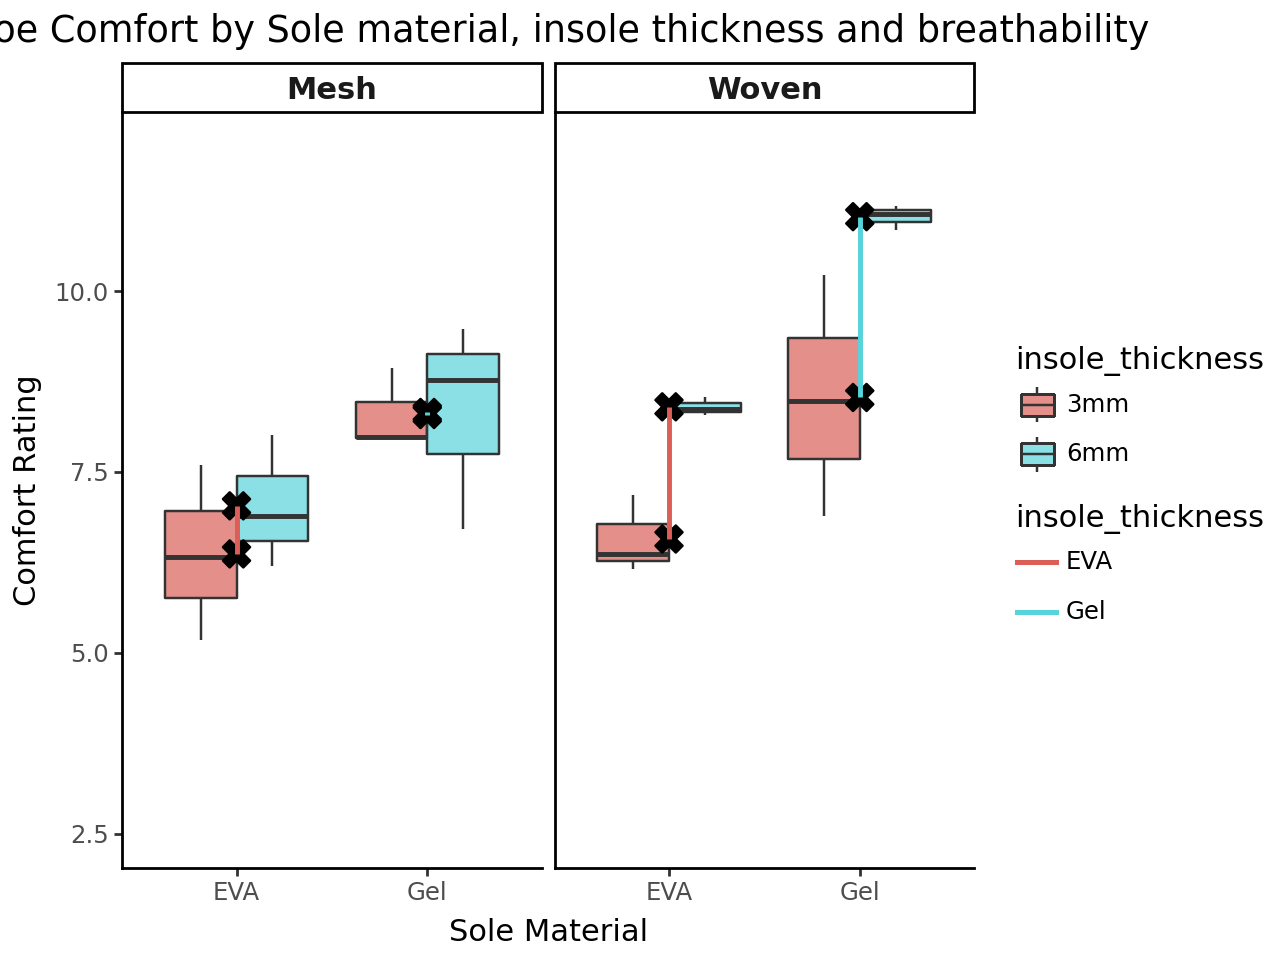

In [15]:
## Question 6 Code ##

import numpy as np
import pandas as pd
import scipy as sp
from scipy import stats
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import *


#p1q6 Import Data#
scexp = pd.read_excel("Shoe Comfort Experiment.xlsx", engine = 'openpyxl')

print("Question 6: Exploratory Data Analysis")
print(scexp.columns.tolist())
print(scexp.describe(include="all").T)

print(scexp.info())

#main effects
print("Main Effects")
#sole material
sole_stats = scexp.groupby("sole_material")["comfort"].agg(['mean','std'])

print(sole_stats)

#insole thickness
insole_stats = scexp.groupby("insole_thickness")["comfort"].agg(['mean','std'])

print(insole_stats)

#breathability
breath_stats = scexp.groupby("breathability")["comfort"].agg(['mean','std'])

print(breath_stats)

#two-way interactions
print("Two-Way Interactions")
#sole x insole
sole_insole_stats = scexp.groupby(["sole_material","insole_thickness"])["comfort"].agg(['mean','std'])
print(sole_insole_stats)

#sole x breathability
sole_breath_stats = scexp.groupby(["sole_material","breathability"])["comfort"].agg(['mean','std'])
print(sole_breath_stats)

#insole x breathability
insole_breath_stats = scexp.groupby(["insole_thickness","breathability"])["comfort"].agg(['mean','std'])
print(insole_breath_stats)

#Three way interactions
print("Three-Way Interactions")

sole_insole_breath_stats = scexp.groupby(["sole_material","insole_thickness","breathability"])["comfort"].agg(['mean','std'])
print(sole_insole_breath_stats)

#prepare summarized data
scexp_means = sole_insole_breath_stats.reset_index()[['sole_material','insole_thickness','breathability', 'mean']]

box_dodge = position_dodge(0.75)

p = (
    ggplot(scexp, aes(x='sole_material',y='comfort')) +
    geom_boxplot(aes(fill='insole_thickness'), alpha = 0.7, position = box_dodge) +
    #mean points
    geom_point(
        data=scexp_means,
        mapping=aes(y='mean', group='sole_material'),
        shape='X',
        size=5,
        position=box_dodge,
        color='black',
    ) +
#mean lines
    geom_line(
        data=scexp_means,
        mapping=aes(y='mean', group='sole_material', color='sole_material'),
        size=1.2,
        position=box_dodge
    ) +
    #facet by breathability
    facet_wrap('~breathability', ncol=2) +
    #format
    labs(title = "Shoe Comfort by Sole material, insole thickness and breathability",
    x = "Sole Material",
    y = "Comfort Rating",
    fill = "insole_thickness",
    color = "insole_thickness") +

    theme_classic() +
    theme(
        plot_title = element_text(hjust=0.5),
        strip_text = element_text(size=11, weight='bold')
    ) +

    scale_y_continuous(limits=(2.5, 12))
)

p

7.  Fit a full factorial ANOVA model to the data. Assess the normality assumption using both a visual method and a testing method. Do we have evidence to support the assumption of normality? Why or why not?


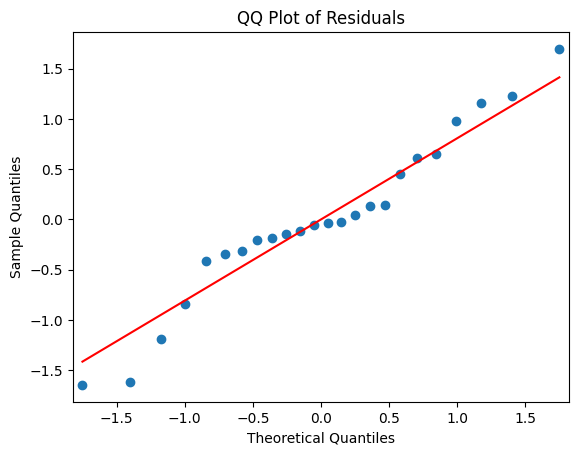

Shapiro-Wilk Test Results:
Statistic: 0.959532741725587
p-value: 0.42910705030991836
Fail to reject the null hypothesis - Residuals are normally distributed.


In [16]:
## Question 7 Code ##

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

model = ols('comfort ~ sole_material * insole_thickness * breathability', data=scexp).fit()

residuals = model.resid

#test normality
#QQ plot
sm.qqplot(residuals, line='s')
plt.title('QQ Plot of Residuals')
plt.show()

#shapiro wilks test

shapiro_test = stats.shapiro(residuals)

print("Shapiro-Wilk Test Results:")
print(f"Statistic: {shapiro_test.statistic}")
print(f"p-value: {shapiro_test.pvalue}")
if shapiro_test.pvalue < 0.05:
    print("Reject the null hypothesis - Residuals are not normally distributed.")
else:
    print("Fail to reject the null hypothesis - Residuals are normally distributed.")


8.  Assess the constant variance assumption using both a visual method and a testing method. Do we have evidence to support the assumption of constant variance? Why or why not?


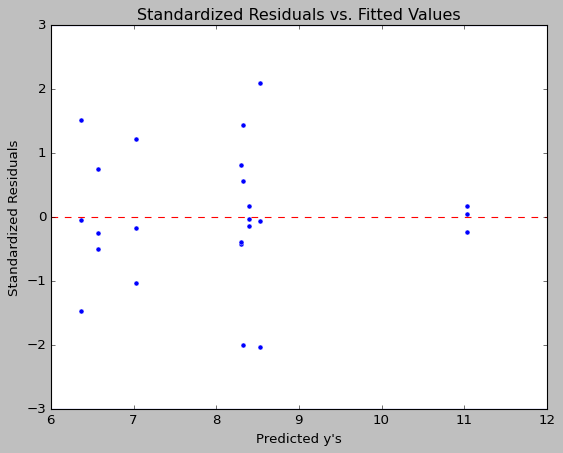

F-statistic: 2.2615166027197584
F p-value: 0.08366429231760693
Fail to reject the null hypothesis - Variances are equal.


In [19]:
## Question 8 Code ##

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

#Scatterplot of Standardized Residuals vs. Fitted Values

#standardized Residuals

standardized_residuals = model.get_influence().resid_studentized_internal

#fit values

fitted_values = model.fittedvalues

#scatterplot


plt.figure(figsize=(8, 6))
sns.scatterplot(x=fitted_values, y=standardized_residuals)
plt.axhline(y=0, linestyle='dashed', color='red')
plt.axhline(y=3, color='blue')
plt.axhline(y=-3, color='blue')
plt.xlabel("Predicted y's")
plt.ylabel("Standardized Residuals")
plt.title("Standardized Residuals vs. Fitted Values")
plt.style.use('classic')
plt.show()

#B-P Test

bp_test = het_breuschpagan(residuals, model.model.exog)

## Extract F-statistic ##

f_statistic = bp_test[2]

## Extract its P-Value ##

f_p_value = bp_test[3]

print(f"F-statistic: {f_statistic}")
print(f"F p-value: {f_p_value}")
if f_p_value < 0.05:
    print("Reject the null hypothesis - Variances are not equal.")
else:
    print("Fail to reject the null hypothesis - Variances are equal.")


9.  Report the F-statistics and their associated p-values from the factorial ANOVA model. What conclusions can we draw about our main effects? Our two-way interactions? Our three-way interaction?


In [20]:
## Question 9 Code ##


anova_table = sm.stats.anova_lm(model, typ=3)

## Add Significance Column ##

anova_table["Significance"] = np.where(anova_table["PR(>F)"] < 0.05, "Significant", "Not Significant")

## Print Table Minus Intercept and Residual Rows ##

print(anova_table.drop(index=["Intercept", "Residual"]))

                                                sum_sq   df         F  \
sole_material                                 5.564969  1.0  5.696617   
insole_thickness                              0.661288  1.0  0.676932   
breathability                                 0.063498  1.0  0.065000   
sole_material:insole_thickness                0.303143  1.0  0.310314   
sole_material:breathability                   0.000661  1.0  0.000676   
insole_thickness:breathability                1.013879  1.0  1.037864   
sole_material:insole_thickness:breathability  0.641055  1.0  0.656220   

                                                PR(>F)     Significance  
sole_material                                 0.029691      Significant  
insole_thickness                              0.422739  Not Significant  
breathability                                 0.802009  Not Significant  
sole_material:insole_thickness                0.585197  Not Significant  
sole_material:breathability                  


10. Calculate and interpret the partial $\eta^2$ values for each of the main effects and interactions. Which effects and/or interactions are most important? Why?


In [29]:
## Question 10 Code ##
import statsmodels.api as sm
import pingouin as pg




## Fit ANOVA with pingouin ##

mod_p = pg.anova(dv='comfort',between=["sole_material","insole_thickness","breathability"],data=scexp,effsize="np2").round(4)

print(mod_p[["Source","np2"]])


                                             Source     np2
0                                     sole_material  0.5934
1                                  insole_thickness  0.3765
2                                     breathability  0.3285
3                  sole_material * insole_thickness  0.0000
4                     sole_material * breathability  0.0429
5                  insole_thickness * breathability  0.2405
6  sole_material * insole_thickness * breathability  0.0394
7                                          Residual     NaN



11. Summarize your conclusions. Which combination of factors would you recommend to the shoe manufacturer? Why?



## PART 2 INSTRUCTIONS:
The same company is interested in developing a new GPS-enabled fitness band for runners. They want to maximize user satisfaction and have identified three key factors:

| Run | GPS Accuracy (A) | Battery Life (B) | Display (C) |
|-----|------------------|------------------|-------------|
| 1   | \- (Standard)    | \- (6 hours)     | \- (Small)  |
| 2   | \+ (High)        | \- (6 hours)     | \+ (Large)  |
| 3   | \- (Standard)    | \+ (12 hours)    | \+ (Large)  |
| 4   | \+ (High)        | \+ (12 hours)    | \- (Small)  |

Due to time and resource limitations, the company would rather conduct a $2^{3-1}$ fractional factorial experiment. For each of the above runs, the company will recruit 3 NCAA division one cross-country athletes to test a randomly assigned fitness band. Each athlete will use the band for one month during their competition season. At the end of the month, the athletes will be asked to rate their level of satisfaction on a scale of 1-10 (1 = very dissatisfied, 10 = very satisfied). The results of this experiment are contained in the `Fitness Band Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

2.  Specify the outcome variable and how it is measured.

3.  Specify the independent variables. What lurking variables may be present?

4.  Explain the difference between a full $2^k$ factorial design and a $2^{3-1}$ fractional factorial design. Briefly comment on why the latter may be preferred in this case.

5.  State the sets of null and alternative hypotheses for this experiment.

6.  Assuming a defining relation of $I=ABC$, specify the aliasing structure of the design. What does this mean for the interpretation of the main effects and interactions?

7.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?


In [ ]:
## Question 7 Code ##


8.  Fit the appropriate ANOVA model to the data. Assess the normality assumption using both a testing method and a visual method. Do we have evidence to support the assumption of normality? Why or why not?


In [ ]:
## Question 8 Code ##


9.  Assess the constant variance assumption using both a testing method and a visual method. Do we have evidence to support the assumption of constant variance? Why or why not?


In [ ]:
## Question 9 Code ##

10. Report the F-statistics and their associated p-values from the factorial ANOVA model. What conclusions can we draw about our main effects?

In [ ]:
## Question 10 Code ##

11. Calculate and interpret the values for the main effects. Which effects seem more important? Why?

In [ ]:
## Question 11 Code ##

12. Calculate and interpret the partial $\eta^2$ values for each of the main effects. Which effects are most important? Why?

In [ ]:
## Question 12 Code ##

13. Summarize your conclusions. Which combination of factors would you recommend to the fitness band manufacturer? Why?